In [1]:
import awkward as ak
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema

In [2]:
file = "0dad8c9b-40a2-4767-ad1b-131e22b47924.root"

factory = NanoEventsFactory.from_root(
    f"{file}:Events",
    schemaclass=NanoAODSchema,
)
events = factory.events()

In [3]:
events.fields

['GenIsolatedPhoton',
 'Dataset',
 'SoftActivityJet',
 'Tau',
 'run',
 'GenJet',
 'SoftActivityJetNjets2',
 'GenPart',
 'MC',
 'DST',
 'Photon',
 'PSWeight',
 'L1',
 'boostedTau',
 'genWeight',
 'SubGenJetAK8',
 'OtherPV',
 'CaloMET',
 'DeepMETResolutionTune',
 'HTXS',
 'bunchCrossing',
 'PV',
 'ChsMET',
 'FsrPhoton',
 'SV',
 'IsoTrack',
 'CorrT1METJet',
 'luminosityBlock',
 'HLT',
 'SoftActivityJetHT',
 'L1simulation',
 'GenJetAK8',
 'GenVtx',
 'RawMET',
 'SoftActivityJetHT5',
 'HLTriggerFirstPath',
 'SubJet',
 'DeepMETResponseTune',
 'RawPuppiMET',
 'genTtbarId',
 'GenVisTau',
 'SoftActivityJetNjets10',
 'LowPtElectron',
 'Muon',
 'BeamSpot',
 'MET',
 'TkMET',
 'L1Reco',
 'HLTriggerFinalPath',
 'PuppiMET',
 'GenDressedLepton',
 'SoftActivityJetHT2',
 'GenMET',
 'Pileup',
 'Electron',
 'FatJet',
 'Rho',
 'GenProton',
 'SoftActivityJetNjets5',
 'Jet',
 'event',
 'Generator',
 'TrigObj',
 'SoftActivityJetHT10',
 'TauProd',
 'Flag']

In [10]:
events.MC.fields

['Run3_PFScoutingPixelTracking']

In [13]:
photons = events.GenPart[
    (events.GenPart.pdgId == 22) & (events.GenPart.status == 1)
]

mask = ak.num(photons) >= 2
photons = photons[mask]

photons = photons[ak.argsort(photons.pt, ascending=False)]

lead = photons[:,0]
sublead = photons[:,1]

mgg = (lead + sublead).mass

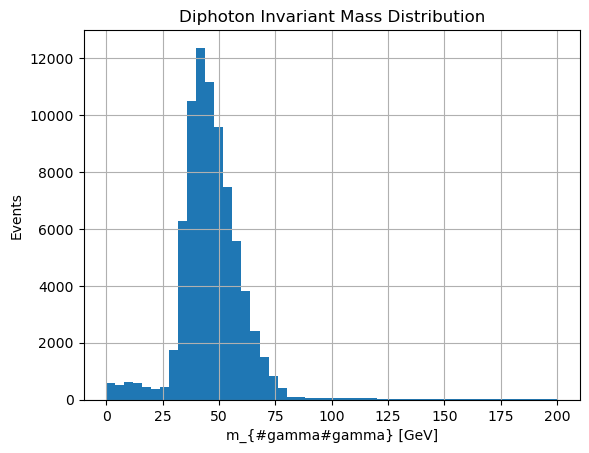

In [14]:
import matplotlib.pyplot as plt
plt.hist(mgg, bins=50, range=(0, 200))
plt.xlabel("m_{#gamma#gamma} [GeV]")
plt.ylabel("Events")
plt.title("Diphoton Invariant Mass Distribution")
plt.grid()